# Predictive Alerting for Cloud Metrics
## Part 2: Modeling and Evaluation

**Approach:** Sliding window binary classification — given the last W=12
data points (1 hour at 5-min intervals), predict whether an incident
occurs within the next H=6 points (30 minutes).

**Methods compared:**
1. MAD baseline (robust rolling z-score)
2. XGBoost on raw windows
3. XGBoost on engineered features (mean, std, slope, sin/cos hour)
4. Prophet (forecasting → residual → threshold)
5. 1D CNN on raw windows (Deep Learning)
6. 1D CNN + Temporal Attention + Focal Loss (Deep Learning)

**Evaluation:** TimeSeriesSplit (5 folds), PR-AUC as primary metric,
threshold tuned on train only (no data leakage).

**References:**
- Fawaz et al., 2019 — "Deep Learning for Time Series Classification: A Review"
- Lin et al., 2017 — "Focal Loss for Dense Object Detection"
- Bahdanau et al., 2015 — "Neural Machine Translation by Jointly Learning to Align and Translate"
- Lavin & Ahmad, 2015 — "Evaluating Real-Time Anomaly Detection Algorithms — the Numenta Anomaly Benchmark"
- Chen & Guestrin, 2016 — "XGBoost: A Scalable Tree Boosting System"


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

from src.config import *
from src.data_loader import load_labeled_series, get_interval_minutes
from src.sliding_windows import make_raw_windows, make_feature_windows
from src.baselines import mad_baseline_scores, eval_mad_baseline
from src.evaluation import compute_pr_auc_f1, find_threshold_on_train
from src.models_xgboost import eval_xgboost_tscv
from src.models_dl import CNN1D, AttentionCNN, FocalLoss, eval_dl_tscv
from src.lead_time import compute_lead_time


### Sliding Window Formulation

We frame incident prediction as binary classification on fixed-size windows:

- **W = 12** (window size): 12 points × 5 min = 1 hour of history.
  One hour captures daily load patterns without diluting recent signals.
- **H = 6** (prediction horizon): 6 points × 5 min = 30 min ahead.
  Gives a DevOps team realistic time to respond before escalation.

For each position t in the time series:
- Input: `values[t-W : t]` — the W points *before* t (not including t)
- Label: 1 if *any* anomaly in `labels[t : t+H]`, else 0

No overlap between input and label — this prevents the model from
simply detecting an ongoing anomaly rather than predicting a future one.


In [20]:
# Load selected files from EDA (excluding irregular + no-anomaly files)
# Re-run filtering logic to be self-contained

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
files_to_exclude = set()

for f in files:
    df = load_labeled_series(os.path.join(DATA_DIR, f))
    max_gap = df['timestamp'].diff().max()
    if max_gap > pd.Timedelta('5 minutes'):
        files_to_exclude.add(f)
    if df['is_anomaly'].sum() == 0:
        files_to_exclude.add(f)

selected_files = sorted([f for f in files if f not in files_to_exclude])
print(f"Selected files: {len(selected_files)}")

# Build datasets: raw windows + feature windows for each file
raw_data = {}
feat_data = {}

for f in selected_files:
    df = load_labeled_series(os.path.join(DATA_DIR, f))
    vals = df['value'].values
    labels = df['is_anomaly'].values
    ts = df['timestamp'].values

    X_raw, y_raw = make_raw_windows(vals, labels)
    X_feat, y_feat, feat_names = make_feature_windows(vals, ts, labels)

    raw_data[f] = (X_raw, y_raw)
    feat_data[f] = (X_feat, y_feat)

    print(f"  {f:45s} {len(X_raw):10d} windows, {y_raw.sum():5d} incidents ({100*y_raw.mean():.1f}%)")

print(f"\nFeatures: {feat_names}")


Selected files: 9
  ec2_cpu_utilization_24ae8d.csv                      4014 windows,   412 incidents (10.3%)
  ec2_cpu_utilization_53ea38.csv                      4014 windows,   412 incidents (10.3%)
  ec2_cpu_utilization_5f5533.csv                      4014 windows,   412 incidents (10.3%)
  ec2_cpu_utilization_77c1ca.csv                      4014 windows,   408 incidents (10.2%)
  ec2_cpu_utilization_fe7f93.csv                      4014 windows,   420 incidents (10.5%)
  ec2_disk_write_bytes_c0d644.csv                     4014 windows,   420 incidents (10.5%)
  grok_asg_anomaly.csv                                4603 windows,   480 incidents (10.4%)
  iio_us-east-1_i-a2eb1cd9_NetworkIn.csv              1225 windows,   136 incidents (11.1%)
  rds_cpu_utilization_e47b3b.csv                      4014 windows,   412 incidents (10.3%)

Features: ['mean', 'std', 'min', 'max', 'last', 'slope', 'diff_mean', 'sin_hour', 'cos_hour']


### Baseline: Rolling MAD (Median Absolute Deviation)

A robust alternative to Z-score. For each window, we compare the last
value against the window's median using MAD instead of standard deviation.
MAD is resistant to outliers — a single spike does not inflate the scale
estimate, unlike std which is heavily affected by extreme values.

The scaling constant 0.6745 makes MAD equivalent to std for normally
distributed data (consistency factor).

This baseline has no learning — it applies the same rule to every window
regardless of history. If ML models cannot beat this, they add no value.


In [21]:
print("=== MAD Baseline ===\n")
mad_results = {}
for f, (X, y) in raw_data.items():
    # Use last 30% as test (same chronological split as holdout)
    split = int(len(X) * TRAIN_RATIO)
    X_test, y_test = X[split:], y[split:]
    if y_test.sum() == 0:
        continue
    pr_auc, f1 = eval_mad_baseline(f, X_test, y_test)
    mad_results[f] = {'pr_auc': pr_auc, 'f1': f1}
    


=== MAD Baseline ===

  ec2_cpu_utilization_24ae8d.csv                PR-AUC=0.3424 | F1=0.51
  ec2_cpu_utilization_5f5533.csv                PR-AUC=0.1515 | F1=0.29
  ec2_disk_write_bytes_c0d644.csv               PR-AUC=0.0581 | F1=0.21
  grok_asg_anomaly.csv                          PR-AUC=0.1211 | F1=0.23


In [22]:
from sklearn.model_selection import TimeSeriesSplit

print("=== MAD Baseline (TSCV) ===\n")
mad_results = {}
for f, (X, y) in raw_data.items():
    print(f"--- {f} ---")
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    folds = []
    for fold_i, (tr_idx, te_idx) in enumerate(tscv.split(X)):
        y_te = y[te_idx]
        X_te = X[te_idx]
        if y_te.sum() == 0:
            print(f"  Fold {fold_i+1}: skipped (no anomalies)")
            continue
        scores = mad_baseline_scores(X_te)
        pr_auc, f1 = compute_pr_auc_f1(y_te, scores)
        folds.append({'pr_auc': pr_auc, 'f1': f1})
        print(f"  Fold {fold_i+1}: PR-AUC={pr_auc:.4f} | F1={f1:.3f} | "
              f"test={len(X_te)} incidents={int(y_te.sum())}")

    if folds:
        mad_results[f] = {
            'pr_auc': np.mean([r['pr_auc'] for r in folds]),
            'f1': np.mean([r['f1'] for r in folds]),
        }
        print(f"  MEAN: PR-AUC={mad_results[f]['pr_auc']:.4f}\n")
    

=== MAD Baseline (TSCV) ===

--- ec2_cpu_utilization_24ae8d.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: skipped (no anomalies)
  Fold 4: skipped (no anomalies)
  Fold 5: PR-AUC=0.6145 | F1=0.762 | test=669 incidents=412
  MEAN: PR-AUC=0.6145

--- ec2_cpu_utilization_53ea38.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.3224 | F1=0.476 | test=669 incidents=206
  Fold 3: PR-AUC=0.1990 | F1=0.334 | test=669 incidents=134
  Fold 4: PR-AUC=0.1099 | F1=0.204 | test=669 incidents=72
  Fold 5: skipped (no anomalies)
  MEAN: PR-AUC=0.2105

--- ec2_cpu_utilization_5f5533.csv ---
  Fold 1: PR-AUC=0.2818 | F1=0.440 | test=669 incidents=184
  Fold 2: PR-AUC=0.0277 | F1=0.064 | test=669 incidents=22
  Fold 3: skipped (no anomalies)
  Fold 4: PR-AUC=0.2818 | F1=0.473 | test=669 incidents=206
  Fold 5: skipped (no anomalies)
  MEAN: PR-AUC=0.1971

--- ec2_cpu_utilization_77c1ca.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.3810 | F1=0.

### XGBoost on Raw Windows (TimeSeriesSplit)

Gradient-boosted trees (XGBoost) on the raw 12-value window.
Each of the 12 positions becomes a feature — the model must discover
temporal patterns (trends, spikes) through tree splits alone.

Evaluation uses TimeSeriesSplit with 5 folds to assess stability.
Threshold is tuned on training data for each fold (no data leakage).
`scale_pos_weight` compensates for class imbalance per fold.


In [23]:
print("=== XGBoost Raw Windows (TSCV) ===\n")
xgb_raw_results = {}
for f, (X, y) in raw_data.items():
    print(f"\n--- {f} ---")
    folds = eval_xgboost_tscv(f, X, y)
    if folds:
        xgb_raw_results[f] = {
            'pr_auc': np.mean([r['pr_auc'] for r in folds]),
            'f1': np.mean([r['f1'] for r in folds]),
        }

=== XGBoost Raw Windows (TSCV) ===


--- ec2_cpu_utilization_24ae8d.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: skipped (no anomalies)
  Fold 4: skipped (no anomalies)
  Fold 5: skipped (no anomalies)

--- ec2_cpu_utilization_53ea38.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: PR-AUC=0.3311 | P=0.842 R=0.119 F1=0.209 | thr=0.649 | train=2007 test=669 incidents=134
  Fold 4: PR-AUC=0.1890 | P=0.182 R=0.111 F1=0.138 | thr=0.586 | train=2676 test=669 incidents=72
  Fold 5: skipped (no anomalies)

  MEAN±STD: PR-AUC=0.2601±0.0710 | P=0.512±0.330 R=0.115±0.004 F1=0.174±0.036

--- ec2_cpu_utilization_5f5533.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.0212 | P=0.028 R=0.727 F1=0.054 | thr=0.770 | train=1338 test=669 incidents=22
  Fold 3: skipped (no anomalies)
  Fold 4: PR-AUC=0.4618 | P=0.000 R=0.000 F1=0.000 | thr=0.758 | train=2676 test=669 incidents=206
  Fold 5: skipped (no anomalies)

  MEAN±

### XGBoost Raw Windows: Analysis

XGBoost shows higher PR-AUC than the MAD baseline on some files, though MAD outperforms XGBoost raw on files where most TSCV folds lack training anomalies (e.g., `ec2_cpu_77c1ca`, `ec2_disk_write`) because MAD requires no training labels,
confirming that tree-based models can extract useful temporal patterns
even from raw values. However, recall is often low because the
threshold learned on training data is too conservative for test data.

This gap between ranking quality (PR-AUC) and binary decision quality
(F1) is characteristic of anomaly detection on non-stationary data:
the distribution shifts between time periods, making a fixed threshold
unreliable. This motivates two improvements:
1. Feature engineering to give the model richer representations
2. Deep learning to learn representations end-to-end


### XGBoost on Engineered Features

Instead of 12 raw values, we extract 9 features from each window:

- **Statistical:** mean, std, min, max, last value
- **Trend:** slope (linear regression coefficient) — captures whether
  the metric is rising or falling over the past hour
- **Volatility:** diff_mean (mean absolute change between consecutive
  points) — distinguishes calm periods from turbulent ones
- **Temporal:** sin_hour, cos_hour — cyclic encoding of time of day.
  CPU at 80% during business hours is normal; at 3 AM it is suspicious.
  Cyclic encoding ensures hour 23 and hour 0 are neighbors.


In [24]:
print("=== XGBoost Features (TSCV) ===\n")
xgb_feat_results = {}
for f, (X, y) in feat_data.items():
    print(f"\n--- {f} ---")
    folds = eval_xgboost_tscv(f, X, y)
    if folds:
        xgb_feat_results[f] = {
            'pr_auc': np.mean([r['pr_auc'] for r in folds]),
            'f1': np.mean([r['f1'] for r in folds]),
        }


=== XGBoost Features (TSCV) ===


--- ec2_cpu_utilization_24ae8d.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: skipped (no anomalies)
  Fold 4: skipped (no anomalies)
  Fold 5: skipped (no anomalies)

--- ec2_cpu_utilization_53ea38.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: PR-AUC=0.3811 | P=0.818 R=0.067 F1=0.124 | thr=0.958 | train=2007 test=669 incidents=134
  Fold 4: PR-AUC=0.1884 | P=0.257 R=0.125 F1=0.168 | thr=0.846 | train=2676 test=669 incidents=72
  Fold 5: skipped (no anomalies)

  MEAN±STD: PR-AUC=0.2848±0.0963 | P=0.538±0.281 R=0.096±0.029 F1=0.146±0.022

--- ec2_cpu_utilization_5f5533.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.0703 | P=0.094 R=0.727 F1=0.167 | thr=0.963 | train=1338 test=669 incidents=22
  Fold 3: skipped (no anomalies)
  Fold 4: PR-AUC=0.2719 | P=0.000 R=0.000 F1=0.000 | thr=0.976 | train=2676 test=669 incidents=206
  Fold 5: skipped (no anomalies)

  MEAN±STD

In [25]:
from xgboost import XGBClassifier

# Feature importance on one representative file
demo_file = selected_files[0]
X_demo, y_demo = feat_data[demo_file]
model = XGBClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH,
                      random_state=RANDOM_STATE)
model.fit(X_demo, y_demo, verbose=False)

importance = sorted(zip(feat_names, model.feature_importances_),
                    key=lambda x: x[1], reverse=True)

print(f"Feature Importance ({demo_file}):\n")
for name, imp in importance:
    bar = chr(9608) * int(imp * 50)
    print(f"  {name:<12} {imp:.3f} {bar}")


Feature Importance (ec2_cpu_utilization_24ae8d.csv):

  min          0.318 ███████████████
  sin_hour     0.138 ██████
  max          0.132 ██████
  cos_hour     0.106 █████
  std          0.089 ████
  mean         0.073 ███
  diff_mean    0.070 ███
  last         0.039 █
  slope        0.036 █


### Prophet: Forecasting Approach

An alternative framing: instead of classifying windows directly,
predict the *expected value* of the metric using Prophet (trend + daily
seasonality), then flag large deviations (residuals) as anomalies.

This tests whether anomalies are better caught as classification targets
or as forecast residuals. Threshold for residuals is computed on training
data (mean + 2×std of training residuals) to avoid data leakage.


In [26]:
from prophet import Prophet
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import auc as sk_auc
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)


# Use good_files (anomalies in both train and test for holdout)
good_files_list = []
for f, (X, y) in raw_data.items():
    split = int(len(X) * TRAIN_RATIO)
    if y[:split].sum() > 0 and y[split:].sum() > 0:
        good_files_list.append(f)

def eval_prophet(f_name, threshold_multiplier=2.0):
    df = load_labeled_series(os.path.join(DATA_DIR, f_name))
    split = int(len(df) * TRAIN_RATIO)
    df_train = df.iloc[:split].copy()
    df_test = df.iloc[split:].copy()

    prophet_train = df_train[['timestamp', 'value']].rename(
        columns={'timestamp': 'ds', 'value': 'y'})

    model = Prophet(daily_seasonality=True, weekly_seasonality=False)
    model.fit(prophet_train)

    forecast = model.predict(
        df_test[['timestamp']].rename(columns={'timestamp': 'ds'}))

    residuals = np.abs(df_test['value'].values - forecast['yhat'].values)

    # Threshold from train residuals (no leakage)
    train_forecast = model.predict(prophet_train[['ds']])
    train_resid = np.abs(df_train['value'].values - train_forecast['yhat'].values)
    threshold = train_resid.mean() + threshold_multiplier * train_resid.std()

    y_true = df_test['is_anomaly'].values
    prec, rec, _ = precision_recall_curve(y_true, residuals)
    pr_auc = sk_auc(rec, prec)

    print(f"  {f_name:45s} PR-AUC={pr_auc:.4f} | threshold={threshold:.2f}")
    return pr_auc

print("=== Prophet (Forecasting → Residual) ===\n")
prophet_results = {}
for f in good_files_list:
    prophet_results[f] = eval_prophet(f)


=== Prophet (Forecasting → Residual) ===

  ec2_cpu_utilization_5f5533.csv                PR-AUC=0.1653 | threshold=6.69
  ec2_disk_write_bytes_c0d644.csv               PR-AUC=0.0692 | threshold=190934664.98
  grok_asg_anomaly.csv                          PR-AUC=0.0830 | threshold=3.32


### Prophet: Analysis

Prophet shows PR-AUC 0.07–0.17 on the three files where holdout evaluation was possible — lower than both XGBoost (TSCV) and MAD baseline (TSCV) on the same files.

The forecasting approach fails for cloud anomaly detection because:

1. Prophet models "what value should be" — it does not learn "what pattern
   precedes an incident." Cloud anomalies are often contextual (gradual drift)
   rather than simple threshold breaches.
2. Residual-based detection is point-by-point, losing the temporal context
   that sliding-window classification preserves.
3. With only ~2 weeks of data, Prophet cannot reliably separate trend from
   noise, leading to poor residual calibration.

This confirms that direct classification on sliding windows outperforms
indirect detection through forecast residuals for this task.


### Deep Learning: 1D CNN on Raw Windows

Following Fawaz et al. (2019), who showed that 1D CNNs are competitive
with RNNs across 85 time series benchmarks, we apply a two-layer Conv1d
architecture to raw sliding windows.

**Architecture choice:**
- Two Conv1d layers (16 and 32 filters, kernel=3) — standard FCN structure.
  Kernel size 3 captures 15-minute local patterns; two layers give a
  receptive field of 5 points (25 minutes).
- Model has ~2200 parameters for ~4000 training samples — a compact
architecture where parameters are fewer than samples. Dropout(0.3)
is added as standard regularization to ensure generalization across
the temporal cross-validation folds.
- LSTM was considered but rejected: with W=12, there is no long-range
  dependency to exploit. CNN is more parameter-efficient for short windows.

**Why not LSTM?** LSTM excels at sequences of hundreds of steps where
long-range memory matters. Our 12-point window has no such structure.
CNN finds local patterns (spikes, trends) more efficiently.

Inputs are normalized per fold (train mean/std) to ensure stable gradients.


In [27]:
print("=== 1D CNN on raw windows (TSCV) ===\n")
cnn_results = {}
for f, (X, y) in raw_data.items():
    print(f"\n--- {f} ---")
    folds = eval_dl_tscv(f, X, y, CNN1D)
    if folds:
        cnn_results[f] = {
            'pr_auc': np.mean([r['pr_auc'] for r in folds]),
            'f1': np.mean([r['f1'] for r in folds]),
        }


=== 1D CNN on raw windows (TSCV) ===


--- ec2_cpu_utilization_24ae8d.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: skipped (no anomalies)
  Fold 4: skipped (no anomalies)
  Fold 5: skipped (no anomalies)

--- ec2_cpu_utilization_53ea38.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: PR-AUC=0.3900 | P=0.697 R=0.172 F1=0.275 | thr=0.633 | train=2007 test=669 incidents=134
  Fold 4: PR-AUC=0.2021 | P=0.344 R=0.292 F1=0.316 | thr=0.609 | train=2676 test=669 incidents=72
  Fold 5: skipped (no anomalies)

  MEAN±STD: PR-AUC=0.2960±0.0939 | P=0.521±0.176 R=0.232±0.060 F1=0.296±0.020

--- ec2_cpu_utilization_5f5533.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.0184 | P=0.033 R=1.000 F1=0.064 | thr=0.585 | train=1338 test=669 incidents=22
  Fold 3: skipped (no anomalies)
  Fold 4: PR-AUC=0.4047 | P=0.000 R=0.000 F1=0.000 | thr=0.603 | train=2676 test=669 incidents=206
  Fold 5: skipped (no anomalies)

  MEA

### Deep Learning: CNN + Temporal Attention + Focal Loss

Two improvements over the plain CNN:

**Temporal Attention** (additive self-attention, Bahdanau et al., 2015):
Instead of averaging all temporal positions equally (AdaptiveAvgPool),
the model learns a weight for each position. This allows it to focus on
recent time steps where incident precursors are most likely to appear.

**Focal Loss** (Lin et al., 2017): Standard weighted BCE assigns a fixed
multiplier to the minority class. Focal Loss goes further — it reduces
the loss for well-classified (easy) examples and amplifies it for
ambiguous boundary cases. With gamma=2.0 (paper default), a correctly
classified normal sample with confidence 0.95 contributes almost zero
loss, while an uncertain sample at 0.5 gets full weight. This prevents
the model from spending capacity on trivially normal windows and
forces it to learn the subtle pre-incident patterns.


In [28]:
print("=== CNN + Attention + Focal Loss (TSCV) ===\n")
attn_results = {}
for f, (X, y) in raw_data.items():
    print(f"\n--- {f} ---")
    folds =  eval_dl_tscv(f, X, y, AttentionCNN, use_focal=True)
    if folds:
        attn_results[f] = {
            'pr_auc': np.mean([r['pr_auc'] for r in folds]),
            'f1': np.mean([r['f1'] for r in folds]),
            }
        

=== CNN + Attention + Focal Loss (TSCV) ===


--- ec2_cpu_utilization_24ae8d.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: skipped (no anomalies)
  Fold 4: skipped (no anomalies)
  Fold 5: skipped (no anomalies)

--- ec2_cpu_utilization_53ea38.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: skipped (no anomalies)
  Fold 3: PR-AUC=0.4050 | P=0.487 R=0.142 F1=0.220 | thr=0.412 | train=2007 test=669 incidents=134
  Fold 4: PR-AUC=0.2494 | P=0.262 R=0.222 F1=0.241 | thr=0.389 | train=2676 test=669 incidents=72
  Fold 5: skipped (no anomalies)

  MEAN±STD: PR-AUC=0.3272±0.0778 | P=0.375±0.112 R=0.182±0.040 F1=0.230±0.010

--- ec2_cpu_utilization_5f5533.csv ---
  Fold 1: skipped (no anomalies)
  Fold 2: PR-AUC=0.0287 | P=0.033 R=1.000 F1=0.064 | thr=0.361 | train=1338 test=669 incidents=22
  Fold 3: skipped (no anomalies)
  Fold 4: PR-AUC=0.4750 | P=0.000 R=0.000 F1=0.000 | thr=0.382 | train=2676 test=669 incidents=206
  Fold 5: skipped (no anomalies)

### Detection Lead Time

Lead time measures how many minutes before an incident the system raises
its first alert. High recall means "we caught it" — lead time tells us
"did we catch it early enough to act?"

For each incident start (transition from normal to anomalous in test data),
we search backward for the earliest alert that is not part of a previous
anomaly region. The time difference in minutes is the lead time.


In [29]:
print("=== Lead Time Analysis (XGBoost Features) ===\n")
for f in selected_files:
    df = load_labeled_series(os.path.join(DATA_DIR, f))
    X_feat, y_feat, _ = make_feature_windows(
        df['value'].values, df['timestamp'].values, df['is_anomaly'].values)
    compute_lead_time(f, X_feat, y_feat, df['timestamp'].values,
                      df['is_anomaly'].values, WINDOW_SIZE, HORIZON)


=== Lead Time Analysis (XGBoost Features) ===


=== Lead Time: ec2_cpu_utilization_24ae8d.csv === no incidents in test folds

=== Lead Time: ec2_cpu_utilization_53ea38.csv ===
  Interval: 5 min
  Incidents: 1 | Detected: 1 (100%) | Missed: 0
  Mean: 615 min | Median: 615 min | Min: 615 | Max: 615

=== Lead Time: ec2_cpu_utilization_5f5533.csv ===
  Interval: 5 min
  Incidents: 1 | Detected: 1 (100%) | Missed: 0
  Mean: 240 min | Median: 240 min | Min: 240 | Max: 240

=== Lead Time: ec2_cpu_utilization_77c1ca.csv === no incidents in test folds

=== Lead Time: ec2_cpu_utilization_fe7f93.csv ===
  Interval: 5 min
  Incidents: 2 | Detected: 0 (0%) | Missed: 2

=== Lead Time: ec2_disk_write_bytes_c0d644.csv ===
  Interval: 5 min
  Incidents: 2 | Detected: 1 (50%) | Missed: 1
  Mean: 110 min | Median: 110 min | Min: 110 | Max: 110

=== Lead Time: grok_asg_anomaly.csv ===
  Interval: 5 min
  Incidents: 1 | Detected: 1 (100%) | Missed: 0
  Mean: 1880 min | Median: 1880 min | Min: 1880 | Max: 1

### Precision-Recall Curves

Visual comparison of all methods. PR curves show ranking quality across all possible thresholds — the gray dotted line is the random baseline (precision = anomaly prevalence).
The gray dotted line is the random baseline — precision equal to
the anomaly prevalence. Any useful model should be above this line.


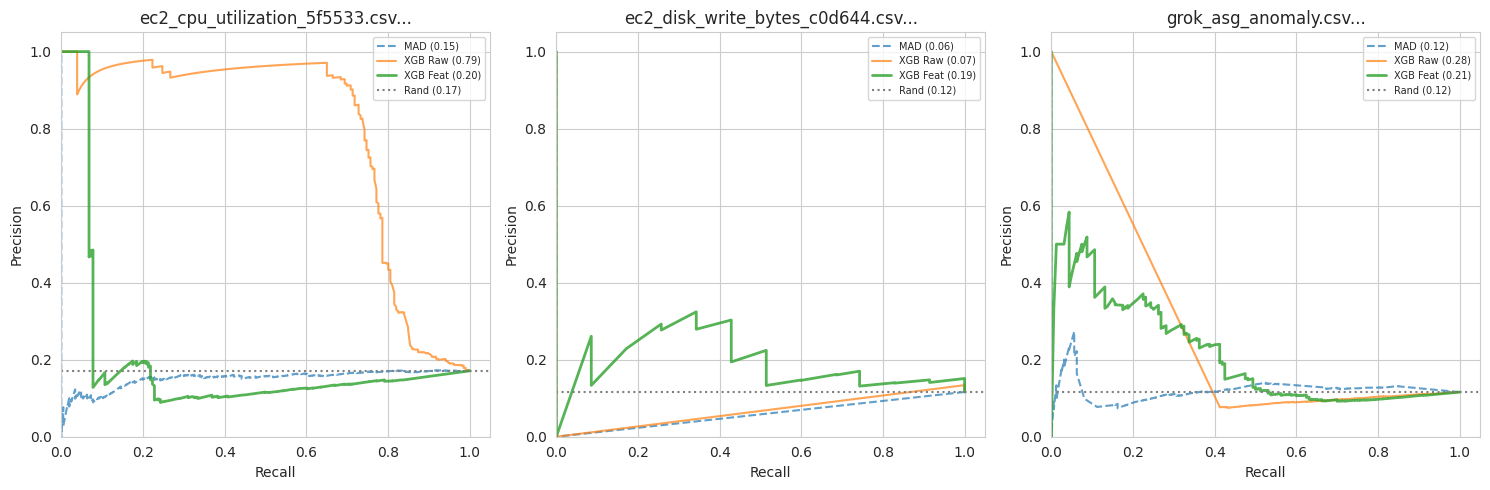

In [39]:
from sklearn.metrics import precision_recall_curve, auc as sk_auc
from xgboost import XGBClassifier
import seaborn as sns
import math

cols = 3
rows = math.ceil(len(good_files_list) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() 
sns.set_style("whitegrid")

for i, f in enumerate(good_files_list):
    ax = axes[i]
    X_raw, y_raw = raw_data[f]
    X_feat, y_feat = feat_data[f]

    split_r = int(len(X_raw) * TRAIN_RATIO)
    split_f = int(len(X_feat) * TRAIN_RATIO)

    # 1. MAD baseline
    scores = mad_baseline_scores(X_raw[split_r:])
    p, r, _ = precision_recall_curve(y_raw[split_r:], scores)
    ax.plot(r, p, '--', alpha=0.7, label=f"MAD ({sk_auc(r,p):.2f})")

    # 2. XGBoost raw
    w = (y_raw[:split_r]==0).sum() / max((y_raw[:split_r]==1).sum(), 1)
    m = XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=w, 
                      eval_metric='aucpr', random_state=42)
    m.fit(X_raw[:split_r], y_raw[:split_r], verbose=False)
    proba = m.predict_proba(X_raw[split_r:])[:,1]
    p, r, _ = precision_recall_curve(y_raw[split_r:], proba)
    ax.plot(r, p, alpha=0.7, label=f"XGB Raw ({sk_auc(r,p):.2f})")

    # 3. XGBoost features
    if y_feat[:split_f].sum() > 0 and y_feat[split_f:].sum() > 0:
        w2 = (y_feat[:split_f]==0).sum() / max((y_feat[:split_f]==1).sum(), 1)
        m2 = XGBClassifier(n_estimators=100, max_depth=4, scale_pos_weight=w2, 
                           eval_metric='aucpr', random_state=42)
        m2.fit(X_feat[:split_f], y_feat[:split_f], verbose=False)
        proba2 = m2.predict_proba(X_feat[split_f:])[:,1]
        p, r, _ = precision_recall_curve(y_feat[split_f:], proba2)
        ax.plot(r, p, lw=2, alpha=0.8, label=f"XGB Feat ({sk_auc(r,p):.2f})")

    # 4. Random baseline
    baseline = y_raw[split_r:].mean()
    ax.axhline(y=baseline, color='gray', ls=':', label=f"Rand ({baseline:.2f})")

    
    ax.set_title(f"{f}...", fontsize=12) 
    ax.set_xlabel('Recall', fontsize=10)
    ax.set_ylabel('Precision', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim([0, 1.05])
    ax.set_ylim([0, 1.05])
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Summary Table

All methods compared on the same files using TimeSeriesSplit (5 folds).
PR-AUC is the primary metric (threshold-independent ranking quality).
Mean ± std across evaluated folds is reported where available.


In [31]:
print("=" * 75)
print(f"  {'File':<40} {'MAD':>6} {'XGB-R':>6} {'XGB-F':>6} {'CNN':>6} {'A-CNN':>6}")
print("=" * 75)

def fmt(d,f):
    v = d.get(f, {}).get('pr_auc')
    return f"{v:.3f}" if v is not None else "  —  "
    
for f in selected_files:
    print(f"  {f:<40} {fmt(mad_results,f):>6} {fmt(xgb_raw_results,f):>6} "
          f"{fmt(xgb_feat_results,f):>6} {fmt(cnn_results,f):>6} {fmt(attn_results,f):>6}")

print("=" * 75)
print("  All methods evaluated using 5-fold TimeSeriesSplit.\n"
      "  MAD evaluates on more folds than supervised methods (no training labels required).\n"
      "  All values are mean PR-AUC across TSCV folds")
print("  MAD=MAD baseline; XGB-R=XGBoost raw; XGB-F=XGBoost features;"
      "  CNN=1D CNN; A-CNN=Attention CNN + Focal Loss")



  File                                        MAD  XGB-R  XGB-F    CNN  A-CNN
  ec2_cpu_utilization_24ae8d.csv            0.615    —      —      —      —  
  ec2_cpu_utilization_53ea38.csv            0.210  0.260  0.285  0.296  0.327
  ec2_cpu_utilization_5f5533.csv            0.197  0.242  0.171  0.212  0.252
  ec2_cpu_utilization_77c1ca.csv            0.291  0.162  0.155  0.158  0.156
  ec2_cpu_utilization_fe7f93.csv            0.312  0.583  0.501  0.537  0.452
  ec2_disk_write_bytes_c0d644.csv           0.266  0.136  0.273  0.180  0.173
  grok_asg_anomaly.csv                      0.250  0.227  0.313  0.186  0.152
  iio_us-east-1_i-a2eb1cd9_NetworkIn.csv    0.717  0.739  0.894  0.857  0.857
  rds_cpu_utilization_e47b3b.csv            0.318  0.341  0.601  0.765  0.262
  All methods evaluated using 5-fold TimeSeriesSplit.
  MAD evaluates on more folds than supervised methods (no training labels required).
  All values are mean PR-AUC across TSCV folds
  MAD=MAD baseline; XGB-R=XGBoost 

### Additional Validation: Pryshlyak Seasonal Dataset

To test whether the approach generalizes beyond NAB, we apply it to
the Pryshlyak seasonal time series dataset — synthetic data with three
anomaly types: collective down, collective up, and point anomaly.

This dataset was designed for unsupervised methods (autoencoders):
training data is purely normal, anomalies exist only in test files.
For supervised classification we concatenate train + test and use
holdout evaluation with the split placed before the anomaly region.


In [32]:
PRYS_URL = "https://huggingface.co/datasets/pryshlyak/seasonal_time_series_for_anomaly_detection/resolve/main/"

pryshlyak_pairs = [
    ("art_monday.csv", "art_monday_collective_anomaly_down.csv", "Collective Down"),
    ("art_wednesday.csv", "art_wednesday_collective_anomaly_up.csv", "Collective Up"),
    ("art_saturday.csv", "art_saturday_point_anomaly.csv", "Point Anomaly"),
]

for train_f, test_f, anom_type in pryshlyak_pairs:
    print(f"\n{'='*50}")
    print(f"{anom_type}: {test_f}")

    df_tr = pd.read_csv(PRYS_URL + train_f)
    df_te = pd.read_csv(PRYS_URL + test_f)

    # Labels: where test differs from train
    diff = (df_te['value'] - df_tr['value']).abs()
    is_anom = (diff > 0.01).astype(int).values

    # Concatenate: normal (train file) + anomalous (test file)
    combined_vals = np.concatenate([df_tr['value'].values, df_te['value'].values])
    combined_labels = np.concatenate([np.zeros(len(df_tr)), is_anom])

    n_anom = int(combined_labels.sum())
    print(f"  Combined: {len(combined_vals)} points, anomalies: {n_anom}")

    X, y = make_raw_windows(combined_vals, combined_labels)

    # Holdout split before anomaly region
    anom_start = len(df_tr) + np.argmax(is_anom == 1)
    split = max(anom_start - WINDOW_SIZE, 100)

    if split < len(X) - 100:
        scores = mad_baseline_scores(X[split:])
        pr_mad, _ = compute_pr_auc_f1(y[split:], scores)
        print(f"  MAD baseline: PR-AUC={pr_mad:.3f}")



Collective Down: art_monday_collective_anomaly_down.csv
  Combined: 7488 points, anomalies: 288
  MAD baseline: PR-AUC=0.339

Collective Up: art_wednesday_collective_anomaly_up.csv
  Combined: 7488 points, anomalies: 287
  MAD baseline: PR-AUC=0.327

Point Anomaly: art_saturday_point_anomaly.csv
  Combined: 7488 points, anomalies: 1
  MAD baseline: PR-AUC=0.002


### Pryshlyak: Analysis

The Pryshlyak dataset reveals a fundamental limitation of supervised
classification: it requires labeled anomalies in training data.
When only normal behavior is available (cold start), unsupervised
methods (autoencoders, isolation forests) are more appropriate.

For collective anomalies (sustained deviations), even the MAD baseline
achieves reasonable detection. Point anomalies (single outlier in 7000+ points) are hard to detect
with aggregated features — one spike out of 12 values barely shifts
window statistics like mean or std. A raw-window CNN could catch the
sharp deviation, but with only one anomalous point there is no
training signal to learn from.

This is consistent with the project's focus: cloud incidents are typically
sustained events (server overload, memory leak, network saturation),
not instantaneous spikes.


### Discussion

**Data Leakage Fix:**
Early experiments tuned the classification threshold on test data,
inflating F1 scores. After correcting this (threshold selected on
training data only), F1 dropped while PR-AUC remained unchanged.
This confirms PR-AUC reflects true ranking quality, while F1 was
artificially boosted. The corrected threshold is often too conservative
for test data, resulting in low recall — a known challenge with
non-stationary time series where "normal" drifts over time.

**Why TimeSeriesSplit shows lower results than holdout:**
A single 70/30 holdout can produce optimistic results if the split
happens to align well with anomaly placement. TSCV with 5 folds tests
the model across multiple time periods. With NAB data (~2 weeks,
anomalies concentrated in 1-2 days), most folds lack anomalies in
either train or test, limiting evaluable folds. This is a dataset
constraint, not a model failure. In production with months of data
and recurring incidents, TSCV would provide robust evaluation.

**XGBoost vs Deep Learning:**
On NAB-scale data (~4000 points), XGBoost with engineered features
and 1D CNN on raw windows show comparable PR-AUC. Neither consistently
dominates. This is consistent with Fawaz et al. (2019) and Grinsztajn
et al. (2022, "Why do tree-based models still outperform deep learning
on tabular data?") — on small tabular datasets, trees and neural
networks perform similarly. Deep learning is expected to outperform
with larger datasets where manual feature engineering cannot capture
all relevant patterns.

**Limitations:**
- NAB dataset is small (2 weeks per metric, ~400 anomalous points)
- Single-metric analysis — no cross-metric correlations (e.g., CPU + network)
- 5-minute sampling limits lead time granularity
- Anomalies are concentrated, making temporal cross-validation difficult

**Production Architecture:**
The project specification describes two Lambda functions:
1. **Daily retraining:** fetch recent CloudWatch metrics, retrain model
   (or recalibrate threshold), save artifacts to S3
2. **Per-minute inference:** load model from S3, take last W points from
   CloudWatch, predict incident probability, alert via SNS if above threshold

Periodic retraining addresses concept drift — the threshold that works
today may be wrong next month as system behavior evolves.

**Future Work:**
- Multi-variate models using covariance between metrics (CPU, network, disk)
- Higher-frequency data (1-min intervals) for better lead time
- LSTM or Transformer for longer windows on production-scale data
- NAB scoring framework for formal early detection evaluation
- Unsupervised pretraining (autoencoder) for cold-start scenarios
